In [4]:
# Load saved interaction maps (.pt) and prepare a few for plotting
from pathlib import Path
import re
import torch

# Base directory where maps are saved by training
base_dir = Path("results/interaction_maps")
if not base_dir.exists():
    print(f"No interaction_maps directory found at {base_dir.resolve()}.")
    print("Run training with map saving enabled, then re-run this cell.")
else:
    # Find epoch_*/ directories and pick the latest numerically
    epoch_dirs = [p for p in base_dir.glob("epoch_*") if p.is_dir()]
    if not epoch_dirs:
        print("No epoch_* directories found under interaction_maps yet.")
    else:
        # Extract integer epoch number; fallback to lexical sort if needed
        def epoch_num(p: Path):
            m = re.search(r"epoch_(\d+)$", p.name)
            return int(m.group(1)) if m else -1
        epoch_dirs.sort(key=epoch_num)
        latest = epoch_dirs[-1]
        print(f"Using latest epoch folder: {latest}")

        # List .pt map files (saved as {'map': Tensor, 'shape': (Nl,Np)})
        pt_files = sorted(latest.glob("map_*.pt"))
        print(f"Found {len(pt_files)} map files in {latest}")

        # Load up to 6 maps
        loaded = []
        for f in pt_files[:20]:
            d = torch.load(f)
            M = d["map"]
            shape = tuple(d.get("shape", tuple(M.shape)))
            loaded.append((f.name, M, shape))
        if loaded:
            print("Loaded:", [name for name, _, _ in loaded])
        else:
            print("No .pt maps found yet in the latest epoch folder.")

Using latest epoch folder: results/interaction_maps/epoch_50
Found 8 map files in results/interaction_maps/epoch_50
Loaded: ['map_000.pt', 'map_001.pt', 'map_002.pt', 'map_003.pt', 'map_004.pt', 'map_005.pt', 'map_006.pt', 'map_007.pt']


/tmp/ipykernel_1484820/868407179.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


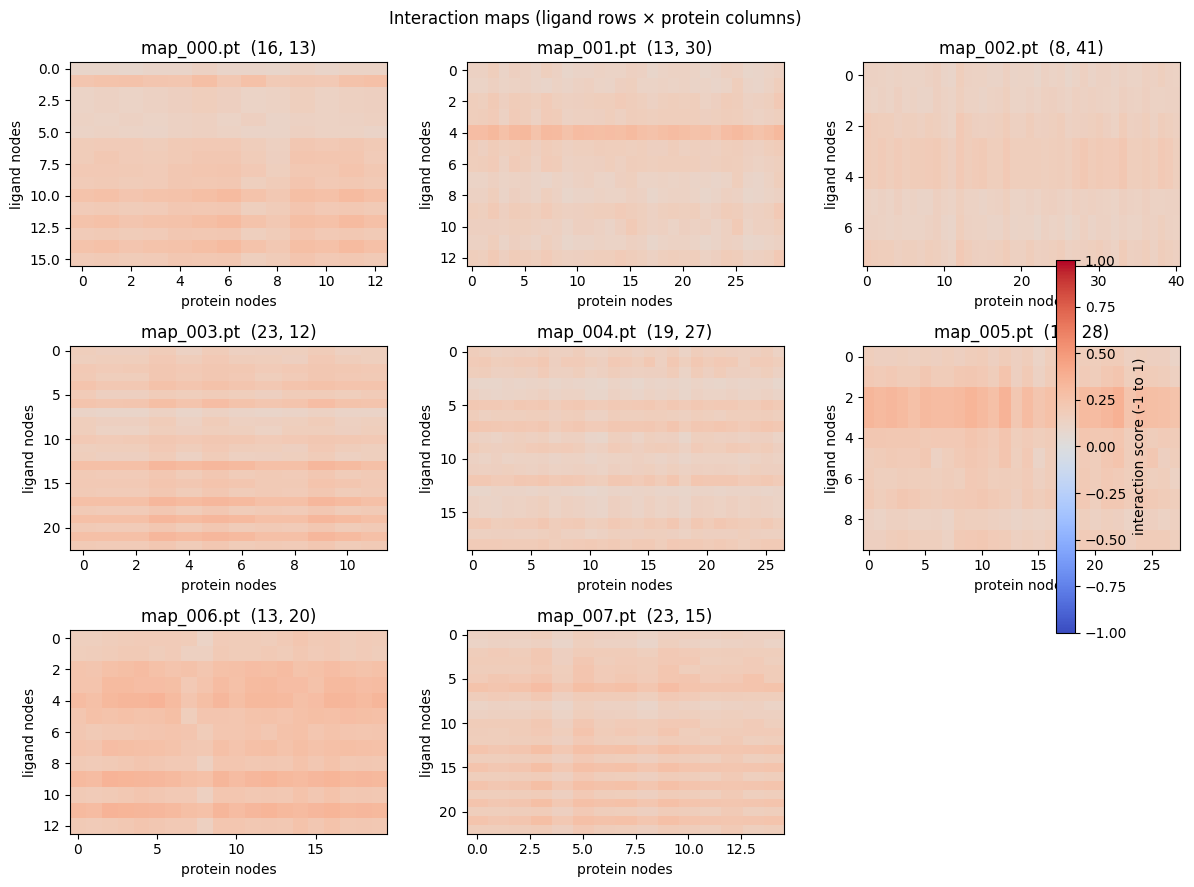

In [5]:
# Visualize loaded interaction maps as heatmaps
# Expects the variable `loaded` from the previous cell

try:
    import matplotlib.pyplot as plt
except Exception as e:
    print("matplotlib not available:", e)
    raise

if 'loaded' not in globals() or not loaded:
    print("Nothing to plot. Run the previous cell to load some maps.")
else:
    n = len(loaded)
    cols = min(3, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), squeeze=False)
    # Keep a consistent color scale since maps are tanh-bounded in [-1, 1]
    vmin, vmax = -1.0, 1.0

    for ax, (name, M, shape) in zip(axes.flatten(), loaded):
        im = ax.imshow(M.detach().cpu().numpy(), cmap='coolwarm', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(f"{name}  {shape}")
        ax.set_xlabel("protein nodes")
        ax.set_ylabel("ligand nodes")
    # Hide any unused subplots
    for ax in axes.flatten()[n:]:
        ax.axis('off')

    # One shared colorbar
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02)
    cbar.set_label("interaction score (-1 to 1)")
    fig.suptitle("Interaction maps (ligand rows × protein columns)")
    fig.tight_layout()
    plt.show()